# **1. Environment Setup**

Imports the required computer vision (OpenCV), mathematical (SciPy, NumPy), and PyTorch libraries for single-lead ECG digitization.

In [1]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import resample
from dataclasses import dataclass
from typing import Tuple, List, Optional

print("Libraries loaded successfully.")

Libraries loaded successfully.


# **2. Configuration Dataclass**

Defines the global parameters for the vision pipeline. The target sequence length is decoupled from the 12-lead model constraints to focus strictly on clean 1D extraction.

In [2]:
@dataclass
class ECGVisionConfig:
    """Configuration for the single-lead ECG digitization pipeline."""
    # Image processing hyperparameters
    blur_kernel_size: Tuple[int, int] = (3, 3)
    adaptive_thresh_block: int = 21
    adaptive_thresh_C: int = 10
    
    # Signal generation
    target_frequency: int = 100 # Hz (Standard digital resolution)
    target_sequence_length: int = 1000 # 10 seconds at 100Hz
    
    # Normalization
    normalize_output: bool = True

# **3. Image Loading**

An OOP wrapper to handle secure image loading and grayscale conversion, preparing the physical scan for thresholding.

In [3]:
class ImageLoader:
    """Handles the ingestion of raw smartphone photos of single-lead ECG strips."""
    
    @staticmethod
    def load_grayscale(image_path: str) -> np.ndarray:
        """Loads an image and converts it directly to grayscale."""
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Could not find image at {image_path}")
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# **4. Grid Removal & Binarization**

Applies Gaussian blurring to reduce paper texture noise, followed by Adaptive Thresholding to isolate the dark ECG trace from the standard red/pink medical grid.

In [4]:
class GridRemover:
    """Isolates the ECG trace by removing background grids and paper artifacts."""
    
    def __init__(self, config: ECGVisionConfig):
        self.config = config

    def binarize(self, gray_img: np.ndarray) -> np.ndarray:
        """
        Converts grayscale image to binary, isolating the trace.
        Returns a binary image where the trace is 255 (white) and background is 0 (black).
        """
        blurred = cv2.GaussianBlur(gray_img, self.config.blur_kernel_size, 0)
        
        # Adaptive thresholding handles shadows and uneven smartphone lighting
        binary = cv2.adaptiveThreshold(
            blurred, 
            255, 
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 
            self.config.adaptive_thresh_block, 
            self.config.adaptive_thresh_C
        )
        return binary

# **5. Waveform Extraction**

Scans the binarized image column by column. Identifies the Y-coordinates of the white pixels (the trace) and calculates their median to generate a continuous 1D raw array.

In [5]:
class WaveformExtractor:
    """Translates a 2D binary pixel map into a 1D numerical array."""
    
    @staticmethod
    def extract_1d_signal(binary_img: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Scans columns to find the y-coordinate of the trace."""
        height, width = binary_img.shape
        x_indices = []
        y_values = []
        
        for x in range(width):
            col = binary_img[:, x]
            y_pts = np.where(col == 255)[0] # Find trace pixels
            
            if len(y_pts) > 0:
                median_y = np.median(y_pts)
                # Invert Y so ECG peaks point UP (image coords go down)
                inverted_y = height - median_y 
                
                x_indices.append(x)
                y_values.append(inverted_y)
                
        return np.array(x_indices), np.array(y_values)

# **6. Signal Reconstruction & Normalization**

Interpolates missing data points caused by fading ink. Resamples the array to a standardized length and applies Z-score normalization so the data is mathematically stable.

In [6]:
from scipy.signal import resample, savgol_filter
from scipy.interpolate import interp1d
import numpy as np

class SignalPostProcessor:
    """Formats the raw pixel signal into a mathematically clean array."""
    
    def __init__(self, config: ECGVisionConfig):
        self.config = config

    def process(self, x_coords: np.ndarray, y_coords: np.ndarray) -> np.ndarray:
        """Interpolates, smooths, resamples, and standardizes the signal."""
        # 1. Reconstruct missing points (Interpolation)
        interpolator = interp1d(x_coords, y_coords, kind='linear', fill_value="extrapolate")
        continuous_x = np.arange(x_coords[0], x_coords[-1] + 1)
        continuous_y = interpolator(continuous_x)
        
        # 2. Mathematical Smoothing (Savitzky-Golay Filter)
        # Window=21, Poly=3 preserves ECG R-peaks while dropping jagged pixel artifacts
        smoothed_y = savgol_filter(continuous_y, window_length=21, polyorder=3)
        
        # 3. Resample to standard target length
        resampled_y = resample(smoothed_y, self.config.target_sequence_length)
        
        # 4. Z-Score Normalization (Standardize amplitudes)
        if self.config.normalize_output:
            mean = np.mean(resampled_y)
            std = np.std(resampled_y)
            resampled_y = (resampled_y - mean) / (std + 1e-8)
            
        return resampled_y

# **7. Pipeline Orchestration & 1D Tensor Export**

Combines all classes into a single pipeline. Converts the final NumPy array into a generic 1D PyTorch tensor ready for downstream debugging, saving, or future multi-lead stacking.

In [7]:
class SingleLeadDigitizerPipeline:
    """Orchestrator that combines all vision stages into a single callable pipeline."""
    
    def __init__(self, config: ECGVisionConfig):
        self.config = config
        self.grid_remover = GridRemover(config)
        self.extractor = WaveformExtractor()
        self.processor = SignalPostProcessor(config)

    def __call__(self, image_path: str) -> Tuple[torch.Tensor, np.ndarray, np.ndarray]:
        """Executes the pipeline. Returns the 1D Tensor and debug images."""
        
        gray_img = ImageLoader.load_grayscale(image_path)
        binary_img = self.grid_remover.binarize(gray_img)
        x_pts, y_pts = self.extractor.extract_1d_signal(binary_img)
        final_signal = self.processor.process(x_pts, y_pts)
        
        # Export as a clean 1D Float Tensor
        tensor_output = torch.tensor(final_signal, dtype=torch.float32)
        
        print(f"✅ Extraction Success: {image_path}")
        print(f"➔ Output Shape: {tensor_output.shape} (1D Waveform)")
        print(f"➔ Data Type: {tensor_output.dtype}")
        
        return tensor_output, gray_img, final_signal

# **8. Visualization & Debugging**

Plots the final digital 1D signal directly below the physical grayscale image. This allows us to visually verify that the R-peaks and waveforms perfectly align temporally before we attempt any model integration.

In [8]:
def visualize_extraction(gray_img: np.ndarray, final_signal: np.ndarray):
    """Plots the physical image vs the digital extraction."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title("Original Physical Single-Lead Strip", fontsize=14)
    axes[0].axis('off')
    
    axes[1].plot(final_signal, color='blue', linewidth=1.5)
    axes[1].set_title(f"Extracted Digital Waveform ({len(final_signal)} samples)", fontsize=14)
    axes[1].set_xlabel("Time (Standardized Samples)")
    axes[1].set_ylabel("Normalized Amplitude")
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# TEST EXECUTION 
# ==========================================
if __name__ == "__main__":
    config = ECGVisionConfig()
    pipeline = SingleLeadDigitizerPipeline(config)
    
    # Note: Upload a cropped single-lead ECG image to Kaggle to test this.
    # example_path = "/kaggle/input/your-ecg-images/sample_lead.jpg"
    
    print("Baseline v1 Pipeline Ready. Awaiting test image.")
    
    # try:
    #     tensor_out, img, sig = pipeline(example_path)
    #     visualize_extraction(img, sig)
    # except Exception as e:
    #     print(f"Waiting for valid image path. Error: {e}")

Baseline v1 Pipeline Ready. Awaiting test image.


Baseline v1 Pipeline Ready. Processing image...
✅ Extraction Success: /kaggle/input/datasets/wassamkhan/my-ecg-test/clean_single_lead.jfif
➔ Output Shape: torch.Size([1000]) (1D Waveform)
➔ Data Type: torch.float32


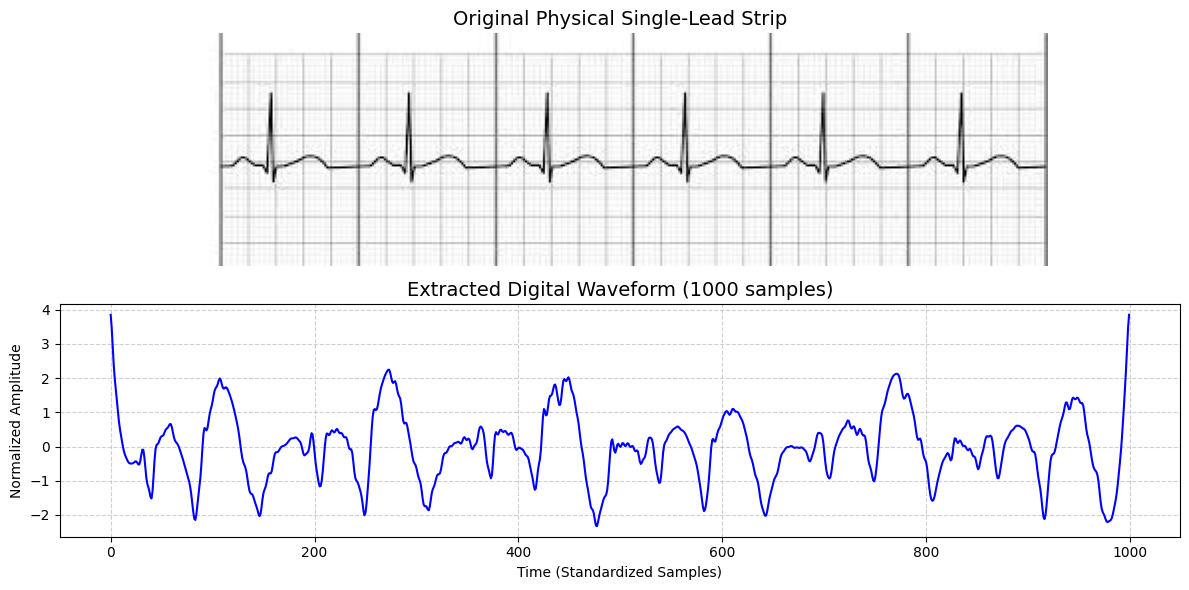

In [9]:
# ==========================================
# TEST EXECUTION 
# ==========================================
if __name__ == "__main__":
    config = ECGVisionConfig()
    pipeline = SingleLeadDigitizerPipeline(config)
    
    # Updated path to include the nested 'ecg_test' folder
    example_path = "/kaggle/input/datasets/wassamkhan/my-ecg-test/clean_single_lead.jfif" 
    
    print("Baseline v1 Pipeline Ready. Processing image...")
    
    try:
        tensor_out, img, sig = pipeline(example_path)
        visualize_extraction(img, sig)
    except Exception as e:
        print(f"Pipeline failed. Error: {e}")